# XGBoost Quote Estimator

Trains two models:
- **XGBRegressor** : predicts `estimated_hours_minimum`, `estimated_hours_maximum`, `estimated_cost`
- **XGBClassifier**: predicts `suggested_ticket_priority_id` (P1-P4)

Inputs: 32-dim PCA-reduced Titan embedding + 6 tabular features = 38 total features

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix
from xgboost import XGBRegressor, XGBClassifier


SEED = 42
np.random.seed(SEED)

NOTEBOOK_DIR = Path().resolve()
MODELS_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = MODELS_ROOT / "data" / "synthetic_tickets.csv"
OUTPUT_DIR = MODELS_ROOT / "output"
ARTIFACTS_DIR = MODELS_ROOT / "handler" / "artifacts"

OUTPUT_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"Data    : {DATA_PATH}")
print(f"Output  : {OUTPUT_DIR}")
print(f"Exists  : {DATA_PATH.exists()}")

Data    : C:\Users\abdul\Desktop\Group Project\SmartQoute\models\data\synthetic_tickets.csv
Output  : C:\Users\abdul\Desktop\Group Project\SmartQoute\models\output
Exists  : True


# 1. Load and Inspect Data

In [32]:
df = pd.read_csv(DATA_PATH)
print (f"Shape: {df.shape}")
df.head(3)

Shape: (2400, 1546)


,ticket_type_id,ticket_severity_id,business_impact_id,users_impacted,deadline_offset_days,is_after_hours,estimated_hours_minimum,estimated_hours_maximum,estimated_cost,suggested_ticket_priority_id,...,embedding_1526,embedding_1527,embedding_1528,embedding_1529,embedding_1530,embedding_1531,embedding_1532,embedding_1533,embedding_1534,embedding_1535
0,1,1,1,90,13.17,0,1.0,4.0,129.69,4,...,-0.274968,-0.023413,-0.018838,-0.042446,0.107888,0.119852,-0.017039,-0.213469,0.061728,0.055536
1,1,1,1,774,17.05,0,1.0,4.0,131.13,3,...,-0.093424,-0.090353,-0.007577,-0.045118,-0.113833,-0.044169,-0.047451,-0.067185,-0.031579,0.117845
2,1,1,1,507,25.29,0,1.0,4.0,126.07,3,...,0.014873,0.128807,-0.029522,0.046761,0.050589,0.150160,-0.170664,-0.045841,0.084852,0.154590


In [33]:
TABULAR_COLS = [
    "ticket_type_id", "ticket_severity_id", "business_impact_id",
    "users_impacted", "deadline_offset_days", "is_after_hours",
]
TARGET_REG = ["estimated_hours_minimum", "estimated_hours_maximum", "estimated_cost"]
TARGET_CLF = "suggested_ticket_priority_id"
EMB_COLS   = [c for c in df.columns if c.startswith("embedding_")]

print(f"Tabular features : {len(TABULAR_COLS)}")
print(f"Embedding dims   : {len(EMB_COLS)}")
print()
print("Priority distribution:")
print(df[TARGET_CLF].value_counts().sort_index())

Tabular features : 6
Embedding dims   : 1536

Priority distribution:
suggested_ticket_priority_id
1     163
2    1152
3     995
4      90
Name: count, dtype: int64


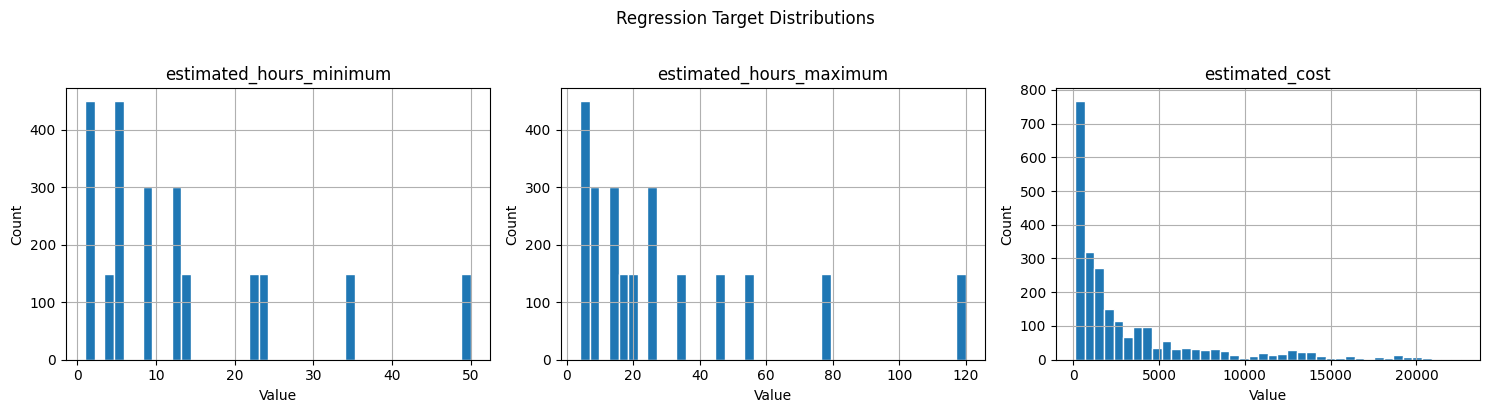

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TARGET_REG):
    df[col].hist(bins=40, ax=ax, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.suptitle("Regression Target Distributions", y=1.02)
plt.tight_layout()
plt.show()

# 2. PCA on Embeddings

Variance explained by 32 components: 8.1%


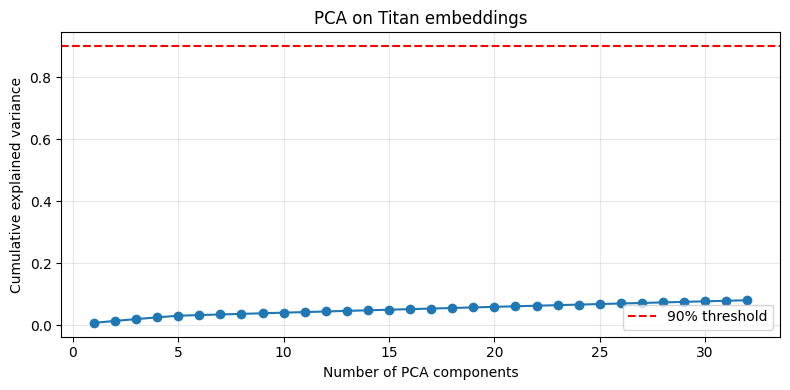

Saved: pca.pkl


In [35]:
PCA_COMPONENTS = 32

X_emb = df[EMB_COLS].values.astype(np.float32)
pca   = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_emb_reduced = pca.fit_transform(X_emb)

explained = pca.explained_variance_ratio_.cumsum()
print(f"Variance explained by {PCA_COMPONENTS} components: {explained[-1]:.1%}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, PCA_COMPONENTS + 1), explained, marker="o", linewidth=1.5)
plt.axhline(0.90, color="red", linestyle="--", label="90% threshold")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on Titan embeddings")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(pca, OUTPUT_DIR / "pca.pkl")
print("Saved: pca.pkl")

# 3. Build Feature Matrix

In [36]:
X_tabular = df[TABULAR_COLS].values.astype(np.float32)
X = np.hstack([X_emb_reduced, X_tabular])

y_reg = df[TARGET_REG].values.astype(np.float32)
y_clf = (df[TARGET_CLF].values - 1).astype(int)     # shift 1-4 -> 0-3 for XGBoost

print(f"Feature matrix : {X.shape}")
print(f"y_reg          : {y_reg.shape}")
print(f"y_clf classes  : {np.unique(y_clf)}")

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Feature matrix : (2400, 38)
y_reg          : (2400, 3)
y_clf classes  : [0 1 2 3]
Train: 1920  Test: 480


# 4. Train XGBRegressor

In [37]:
regressor = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    multi_strategy="multi_output_tree",
    random_state=SEED,
    n_jobs=-1,
)

regressor.fit(X_train, y_reg_train, eval_set=[(X_test, y_reg_test)], verbose=False)
joblib.dump(regressor, OUTPUT_DIR / "regressor.pkl")
print("Saved: regressor.pkl")

Saved: regressor.pkl


In [38]:
y_reg_pred = regressor.predict(X_test)
for i, col in enumerate(TARGET_REG):
    mae = mean_absolute_error(y_reg_test[:, i], y_reg_pred[:, i])
    r2  = r2_score(y_reg_test[:, i], y_reg_pred[:, i])
    print(f"{col:<35}  MAE={mae:>8.2f}  R2={r2:.4f}")

estimated_hours_minimum              MAE=    0.20  R2=0.9969
estimated_hours_maximum              MAE=    0.43  R2=0.9967
estimated_cost                       MAE=  163.89  R2=0.9932


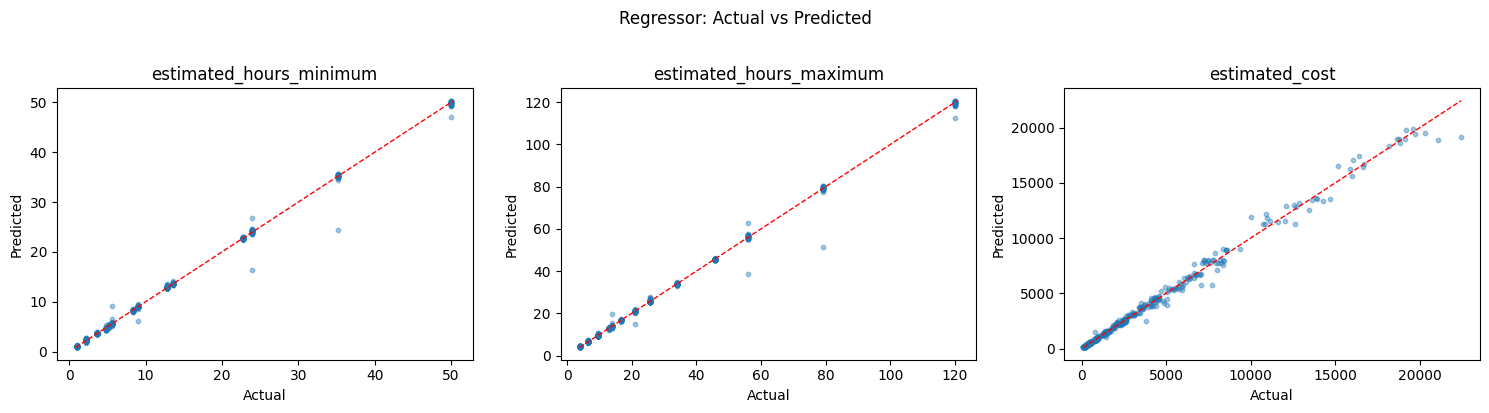

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, col) in enumerate(zip(axes, TARGET_REG)):
    ax.scatter(y_reg_test[:, i], y_reg_pred[:, i], alpha=0.4, s=10)
    lim = [min(y_reg_test[:, i].min(), y_reg_pred[:, i].min()),
           max(y_reg_test[:, i].max(), y_reg_pred[:, i].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
plt.suptitle("Regressor: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

# 5. Train XGBClassifier

In [40]:
classifier = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
)
classifier.fit(X_train, y_clf_train, eval_set=[(X_test, y_clf_test)], verbose=False)
joblib.dump(classifier, OUTPUT_DIR / "classifier.pkl")
print("Saved: classifier.pkl")

Saved: classifier.pkl


In [41]:
y_clf_pred = classifier.predict(X_test)
label_names = ["P1", "P2", "P3", "P4"]
print(classification_report(y_clf_test, y_clf_pred, target_names=label_names))

              precision    recall  f1-score   support

          P1       1.00      0.82      0.90        33
          P2       0.97      0.98      0.97       230
          P3       0.96      0.99      0.97       199
          P4       1.00      0.72      0.84        18

    accuracy                           0.96       480
   macro avg       0.98      0.88      0.92       480
weighted avg       0.97      0.96      0.96       480



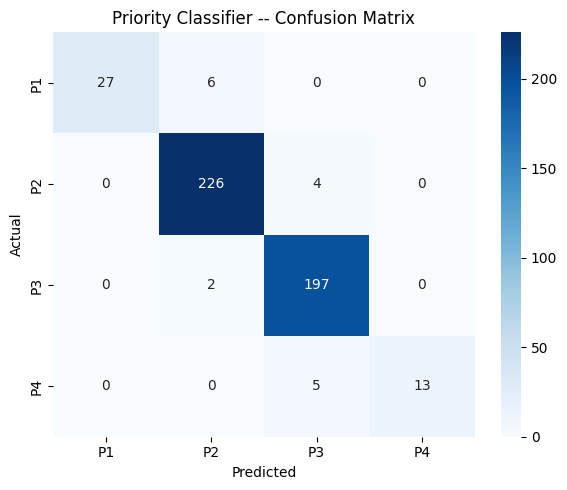

In [42]:
cm = confusion_matrix(y_clf_test, y_clf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Priority Classifier -- Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Feature Importance

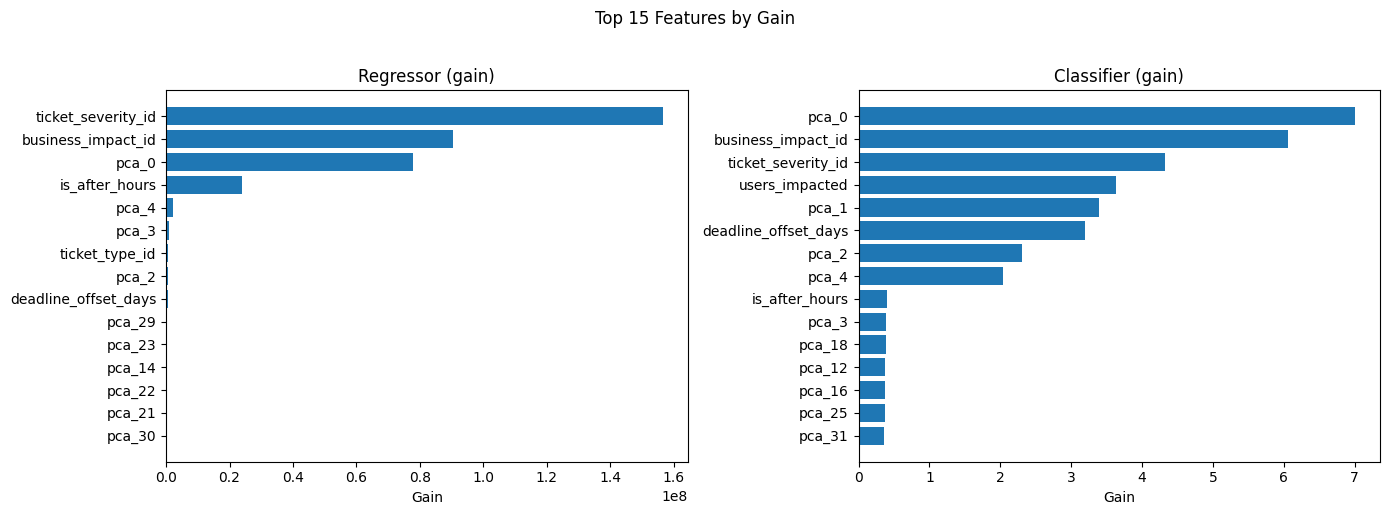

In [43]:
feature_names = [f"pca_{i}" for i in range(PCA_COMPONENTS)] + TABULAR_COLS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in [
    (axes[0], regressor,  "Regressor (gain)"),
    (axes[1], classifier, "Classifier (gain)"),
]:
    scores = model.get_booster().get_score(importance_type="gain")
    named  = {feature_names[int(k[1:])]: v for k, v in scores.items()}
    top_n  = sorted(named.items(), key=lambda x: x[1], reverse=True)[:15]
    names, vals = zip(*top_n)
    ax.barh(names[::-1], vals[::-1])
    ax.set_title(title)
    ax.set_xlabel("Gain")
plt.suptitle("Top 15 Features by Gain", y=1.02)
plt.tight_layout()
plt.show()

# 7. Copy Artifacts for Container Build

In [44]:
import shutil

for fname in ["pca.pkl", "regressor.pkl", "classifier.pkl"]:
    shutil.copy2(OUTPUT_DIR / fname, ARTIFACTS_DIR / fname)
    print(f"Copied {fname} -> {ARTIFACTS_DIR / fname}")

print("\nArtifact sizes:")
for fname in ["pca.pkl", "regressor.pkl", "classifier.pkl"]:
    size_kb = (ARTIFACTS_DIR / fname).stat().st_size / 1024
    print(f"  {fname:<20} {size_kb:>7.1f} KB")

Copied pca.pkl -> C:\Users\abdul\Desktop\Group Project\SmartQoute\models\handler\artifacts\pca.pkl
Copied regressor.pkl -> C:\Users\abdul\Desktop\Group Project\SmartQoute\models\handler\artifacts\regressor.pkl
Copied classifier.pkl -> C:\Users\abdul\Desktop\Group Project\SmartQoute\models\handler\artifacts\classifier.pkl

Artifact sizes:
  pca.pkl                199.3 KB
  regressor.pkl         1960.5 KB
  classifier.pkl        1800.7 KB


# 8. Smoke Test the Handler Locally

In [45]:
import importlib.util
import json

os.environ["MODEL_DIR"] = str(OUTPUT_DIR)

spec = importlib.util.spec_from_file_location("handler", MODELS_ROOT / "handler" / "handler.py")
handler_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(handler_mod)

sample = df.iloc[0]
event = {
    "embedding": sample[EMB_COLS].tolist(),
    "features": {
        col: float(sample[col]) for col in handler_mod.TABULAR_FEATURE_ORDER
    },
}

response = handler_mod.handler(event, None)
print("Status :", response["statusCode"])
print("Body   :", json.dumps(json.loads(response["body"]), indent=2))
print("\nGround truth:")
for t in TARGET_REG + [TARGET_CLF]:
    print(f"  {t}: {sample[t]}")
spec.loader.exec_module(handler_mod)


Status : 200
Body   : {
  "estimated_hours_minimum": 1.17,
  "estimated_hours_maximum": 1.17,
  "estimated_cost": 127.26,
  "suggested_ticket_priority_id": 4,
  "priority_confidence": 0.9987
}

Ground truth:
  estimated_hours_minimum: 1.0
  estimated_hours_maximum: 4.0
  estimated_cost: 129.69
  suggested_ticket_priority_id: 4.0
